# **Modelo Original**

## **Reformulación del Problema: Clasificación Binaria de Desenlaces Graves**

## **Motivo del Cambio**
Como se evidenció en la sección anterior, el modelo XGBoost obtuvo el mejor desempeño en la tarea de clasificación multiclase, evaluado a través de la métrica cuidadosamente seleccionada F1 macro, que ofrece una visión equilibrada del rendimiento en todas las clases, especialmente útil ante la presencia de clases desbalanceadas.


No obstante, con el objetivo de proponer un modelo que logre un desempeño aún más sólido en la identificación de los casos más críticos —aquellos en los que las víctimas de **Violencia Basada en Género (VBG)** en Colombia enfrentan desenlaces graves— se decidió reformular el problema como una **tarea de clasificación binaria**. Esta reformulación tiene como propósito mejorar la precisión en la detección de situaciones de alto riesgo, lo cual resulta clave para el desarrollo futuro de una herramienta que sirva como apoyo en la toma de decisiones por parte de las autoridades y el poder legislativo, permitiendo una actuación más oportuna y eficaz.

### **Redefinición del Objetivo: De Tres a Dos Clases**

Dado el **alto desbalance** en la distribución de clases originales, y en consulta con expertos en el dominio, se optó por consolidar las categorías relacionadas con desenlaces graves. En el conjunto original, la variable `Desenlace_Grave` presentaba tres valores:

* **0**: La víctima sobrevivió y no requirió hospitalización.

* **1**: La víctima sobrevivió, pero requirió hospitalización.

* **2**: La víctima falleció como consecuencia del hecho violento.

Para simplificar y enfocar el problema en la identificación de casos críticos, se redefinió la variable de salida en una **nueva variable binaria**, de la siguiente manera:

+ **Clase 1 (Desenlace Grave)**: incluye a todos los registros donde `Desenlace_Grave` era igual a 1 o 2.

+ **Clase 0 (Sin Desenlace Grave)**: mantiene los registros donde `Desenlace_Grave` era igual a 0.

Este cambio permite enfocar el modelo en la detección temprana de situaciones de alto riesgo, fusionando hospitalización y muerte en una sola categoría de interés prioritario.

### **Aplicación de XGBoost al Nuevo Escenario Binario**
A continuación, se evalúa nuevamente el modelo **XGBoost**, ahora bajo el nuevo esquema binario de clasificación, dado que fue el algoritmo que mostró el mejor desempeño en el escenario multiclase. Esta evaluación permite establecer un nuevo punto de referencia (baseline) sobre el cual se buscará mejorar en secciones posteriores, tanto en términos de desempeño como de interpretabilidad.

Para evaluar el comportamiento del modelo XGBoost bajo la nueva estructura binaria del problema, se mantuvieron las mismas condiciones experimentales empleadas en las pruebas anteriores, a fin de garantizar comparabilidad entre escenarios. En particular, se aplicaron:

* **Validación cruzada estratificada con 5 folds**, preservando la proporción de clases en cada partición, tanto en entrenamiento como en prueba.

* **Técnica de sobremuestreo SMOTE (Synthetic Minority Over-sampling Technique)** aplicada únicamente al conjunto de entrenamiento, con el propósito de mitigar el fuerte desbalance entre clases.



In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import time
from joblib import Memory
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import plotly.figure_factory as ff
import plotly.graph_objects as go
from IPython.display import display, HTML
from imblearn.ensemble import BalancedRandomForestClassifier
from lime.lime_tabular import LimeTabularExplainer
import plotly.figure_factory as ff
import plotly.graph_objects as go
from sklearn.ensemble import StackingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [ ]:
Data = pd.read_csv("/content/drive/MyDrive/DataFinal.csv")
display(Data.head())

,SEMANA,ANO,EDAD,UNI_MED,COD_PAIS_O,COD_DPTO_O,COD_MUN_O,PER_ETN,estrato,GP_DISCAPA,...,Diferencia_NOT_INI,Diferencia_CON_INI,Diferencia_ABS_NOT_CON,TIP_SS_C,TIP_SS_E,TIP_SS_I,TIP_SS_N,TIP_SS_P,TIP_SS_S,Victima_Peligro
0,37,2022,15.0,1,170,8,758,6,1.0,2,...,0,0,0,0,0,0,0,0,1,0
1,9,2022,28.0,1,170,11,1,6,2.0,2,...,0,0,0,1,0,0,0,0,0,0
2,6,2022,31.0,1,170,68,81,6,1.0,2,...,0,0,0,0,0,0,0,0,1,0
3,47,2022,32.0,1,170,25,754,6,2.0,2,...,1,1,0,1,0,0,0,0,0,0
4,21,2022,14.0,1,170,11,1,6,2.0,2,...,1,0,1,0,0,0,0,0,1,1


#### **Stratified Cross Validation**

In [ ]:
# Separación de características y variable objetivo
X = Data.drop(columns=["Victima_Peligro", "Desenlace_Grave"])
y = Data['Victima_Peligro']

# StratifiedKFold con 5 folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
fold = 1

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    train_shape = X_train.shape
    test_shape = X_test.shape

    # Distribución de clases en cada conjunto
    train_dist = y_train.value_counts(normalize=True).sort_index()
    test_dist = y_test.value_counts(normalize=True).sort_index()

    fold_results.append({
        "Fold": fold,
        "Train Shape": train_shape,
        "Test Shape": test_shape,
        "Train Distribution": train_dist,
        "Test Distribution": test_dist
    })
    fold += 1

for result in fold_results:
    display(HTML(f"<h3>Fold {result['Fold']}</h3>"))
    display(HTML(f"<b>Train shape:</b> {result['Train Shape']}<br>"
                 f"<b>Test shape:</b> {result['Test Shape']}"))
    dist_df = pd.DataFrame({
        "Train Distribution": result['Train Distribution'],
        "Test Distribution": result['Test Distribution']
    })
    dist_df = dist_df * 100
    dist_df = dist_df.round(2)
    display(dist_df)
    display(HTML("<hr>"))

,Train Distribution,Test Distribution
Victima_Peligro,,
0,82.97,82.97
1,17.03,17.03


,Train Distribution,Test Distribution
Victima_Peligro,,
0,82.97,82.97
1,17.03,17.03


,Train Distribution,Test Distribution
Victima_Peligro,,
0,82.97,82.97
1,17.03,17.03


,Train Distribution,Test Distribution
Victima_Peligro,,
0,82.97,82.97
1,17.03,17.03


,Train Distribution,Test Distribution
Victima_Peligro,,
0,82.97,82.97
1,17.03,17.03


#### **SMOTE (Synthetic Minority Over-sampling Technique)**

In [ ]:
from IPython.display import HTML, display
import pandas as pd
from imblearn.over_sampling import SMOTE

# Distribución original
display(HTML("<h3>Distribución de clases original (entrenamiento)</h3>"))
# Construir DataFrame con conteos y proporciones
counts_orig = y_train.value_counts().sort_index()
props_orig  = y_train.value_counts(normalize=True).sort_index()
dist_orig = pd.DataFrame({
    'Conteo': counts_orig,
    'Proporción': props_orig
})
# Formatear la salida
display(
    dist_orig.style
        .format({'Proporción': "{:.2%}", 'Conteo': "{:d}"})
)

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

display(HTML("<h3>Distribución de clases después de SMOTE</h3>"))
counts_smote = pd.Series(y_train_smote).value_counts().sort_index()
props_smote  = pd.Series(y_train_smote).value_counts(normalize=True).sort_index()
dist_smote = pd.DataFrame({
    'Conteo': counts_smote,
    'Proporción': props_smote
})
display(
    dist_smote.style
        .format({'Proporción': "{:.2%}", 'Conteo': "{:d}"})
)


,Conteo,Proporción
Victima_Peligro,,
0,337634,82.97%
1,69321,17.03%


,Conteo,Proporción
Victima_Peligro,,
0,337634,50.00%
1,337634,50.00%


#### **Distribución de Clases: Antes y Después de SMOTE**

La distribución original de clases muestra un claro desbalance: aproximadamente el **83%** de los casos corresponden a la clase 0 (sin desenlace grave), mientras que apenas un **17%** pertenecen a la clase 1 (desenlace grave). Esta proporción se mantiene de forma consistente en cada uno de los cinco folds utilizados para validación cruzada estratificada, como se observa en las salidas de entrenamiento y prueba.

Dado este fuerte desbalance, se aplicó **SMOTE** al conjunto de entrenamiento en cada fold, lo cual permitió equilibrar completamente las clases, asignando un **50% de representación** a cada una. Esto asegura que el modelo no se sesgue hacia la clase mayoritaria durante el proceso de entrenamiento.

#### **Análisis Preliminar de la Distribución**
La consistencia de la distribución por folds demuestra que la estratificación fue correctamente aplicada. Esto es fundamental para asegurar que el modelo tenga una representación realista de ambas clases en cada iteración de entrenamiento y evaluación. Adicionalmente, la aplicación de SMOTE permite compensar el desequilibrio y ofrece una mejor oportunidad para que el algoritmo aprenda patrones representativos de los desenlaces graves, sin ignorarlos por su baja frecuencia.

#### **Aplicación XGBoost Binario**

In [ ]:
# Pipeline XGBoost + GridSearchCV
memory = Memory("./cache_dir", verbose=0)

xgb_pipeline = Pipeline([
    ("scaler", StandardScaler(copy=False)),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        n_estimators=200,
        n_jobs=-1,
        random_state=42,
        tree_method="auto",
        use_label_encoder=False,
        eval_metric="logloss"
    ))
], memory=memory)

param_grid = {
    "xgb__n_estimators": [100, 200],
    "xgb__max_depth":    [3, 6]
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    error_score="raise"
)

# Entrenamiento
start_time = time.process_time()
grid_search.fit(X_train_smote, y_train_smote)
training_time = time.process_time() - start_time

best_model = grid_search.best_estimator_
print("Mejores parámetros encontrados:", grid_search.best_params_)

# Predicciones y métricas
y_pred       = best_model.predict(X_test)
y_proba_pos  = best_model.predict_proba(X_test)[:, 1]

report       = classification_report(y_test, y_pred, output_dict=True)
accuracy_glob = report["accuracy"]
roc_auc      = roc_auc_score(y_test, y_proba_pos)

# Matriz de Confusión
cm     = confusion_matrix(y_test, y_pred)
labels = sorted(np.unique(y_test))
z_text = [[str(v) for v in row] for row in cm]

fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=[f"Pred_{l}" for l in labels],
    y=[f"True_{l}" for l in labels],
    annotation_text=z_text,
    colorscale="Purples"
)
fig_cm.update_layout(
    title_text="Matriz de Confusión – XGBoost",
    xaxis=dict(title="Predicción"),
    yaxis=dict(title="Valor Real"),
    font=dict(family="Inter")
)
fig_cm.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_pos)
fig_roc = go.Figure([
    go.Scatter(x=fpr, y=tpr, mode="lines",
               name=f"ROC (AUC={roc_auc:.4f})",
               line=dict(color="darkmagenta", width=3)),
    go.Scatter(x=[0,1], y=[0,1], mode="lines",
               name="Azar", line=dict(color="gray", dash="dash"))
])
fig_roc.update_layout(
    title="Curva ROC – XGBoost",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(family="Inter", size=13, color="black"),
    width=700, height=500
)
fig_roc.show()

# Resumen de métricas
summary_data = {
    "Precision (Macro)": [report["macro avg"]["precision"]],
    "Recall (Macro)"   : [report["macro avg"]["recall"]],
    "F1-score (Macro)" : [report["macro avg"]["f1-score"]],
    "Accuracy"         : [accuracy_glob],
    "AUC"              : [roc_auc],
    "Training Time (s)": [training_time]
}
summary_df = pd.DataFrame(summary_data)
display(HTML("<h2>Resumen de Métricas – XGBoost</h2>"))
display(summary_df.style.format("{:.4f}"))

# LIME
explainer = LimeTabularExplainer(
    training_data=X_train_smote.values,
    feature_names=X_train_smote.columns.tolist(),
    class_names=["No Peligro", "Peligro"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

idx = 0
exp = explainer.explain_instance(
    data_row=X_test.values[idx],
    predict_fn=best_model.predict_proba,
    num_features=5
)

lime_list = exp.as_list()
features, weights = zip(*lime_list)
colors = ['#6A0DAD' if w > 0 else '#DDA0DD' for w in weights]

fig_lime = go.Figure(go.Bar(
    x=list(weights),
    y=list(features),
    orientation='h',
    marker=dict(color=colors)
))
fig_lime.update_layout(
    title_text="Explicación LIME – XGBoost",
    xaxis_title="Peso de la característica",
    yaxis_title="Características",
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Inter", color="black"),
    width=700, height=500
)
fig_lime.show()


Mejores parámetros encontrados: {'xgb__max_depth': 6, 'xgb__n_estimators': 200}


,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC,Training Time (s)
0,0.7232,0.6566,0.6792,0.8446,0.8143,61.8566


#### **Resultados del Modelo XGBoost en Clasificación Binaria**

Tras ajustar el modelo XGBoost al nuevo enfoque binario, se realizó una optimización de hiperparámetros utilizando búsqueda en malla, obteniendo como mejores valores:

- **`max_depth`**: 6

- **`n_estimators`**: 200

El modelo fue entrenado con las condiciones descritas anteriormente (validación cruzada estratificada, aplicación de SMOTE, evaluación sobre datos no balanceados). A continuación, se presentan los principales resultados obtenidos.

1. **Matriz de Confusión**: De un total de casos reales con desenlace grave (clase 1), el modelo identificó correctamente 10,891 instancias, mientras que cometió 6,439 falsos negativos (es decir, clasificó incorrectamente como no graves). En la clase 0 (sin desenlace grave), acertó en 79,489 casos, pero incurrió en 4,919 falsos positivos. Este resultado sugiere que el modelo tiende a ser más conservador, priorizando la precisión sobre la sensibilidad, lo que se confirma con las métricas globales.

2. **Curva ROC y AUC**: La curva ROC del modelo presenta un área bajo la curva (AUC) de 0.8143, lo cual indica una buena capacidad discriminativa entre las clases. El modelo logra un equilibrio aceptable entre tasa de verdaderos positivos y falsos positivos a lo largo de diferentes umbrales.

3. **Métricas de Desempeño**
La métrica F1 Macro (0.6792) representa una mejora respecto a configuraciones anteriores y reafirma el buen desempeño del modelo en un contexto con clases desbalanceadas. No obstante, el recall macro aún presenta margen de mejora, particularmente en la clase minoritaria.

4. **Interpretabilidad del Modelo con LIME**
A través de LIME (Local Interpretable Model-agnostic Explanations), se identificaron las características con mayor peso en la predicción de desenlaces graves:

* **`TIP_SS_I` = 0.00**: Esta condición (posiblemente ausencia de cierto tipo de seguridad social) fue la de mayor contribución positiva a predecir un desenlace grave.

* **`GP_OTROS` <= 1.00**: Indica que la pertenencia a ciertos grupos poblacionales también tuvo un impacto importante.

* Estrato bajo y edad mayor a 29 años también estuvieron asociados a mayor riesgo. Estos resultados permiten entender los factores sociales que más influyen en el desenlace de las víctimas, lo que es especialmente valioso para diseñar políticas públicas focalizadas.


```{note}

Es fundamental señalar que el presente proyecto fue desarrollado únicamente con base en la información disponible en la primera hoja del formulario oficial “**875_Violencia_Genero_2024**”, correspondiente a la ficha de Datos Básicos. Esta sección del formulario contiene principalmente variables generales como el departamento y municipio donde ocurrieron los hechos, el tipo de régimen en salud, el estrato socioeconómico, la edad, el sexo, la nacionalidad, así como la pertenencia étnica, el grupo poblacional al que pertenece la víctima y la condición final del caso (vivo, hospitalizado o fallecido).

No obstante, no se contó con acceso a la segunda hoja del formulario, la cual incluye información complementaria que, de acuerdo con expertos en violencia basada en género que participaron en este trabajo, resulta altamente relevante para el desarrollo de modelos predictivos más precisos. Esta segunda parte recoge datos como el tipo y la modalidad de la violencia sufrida (física, psicológica, sexual, negligencia), el contexto específico del hecho (lugar, mecanismo de agresión, ámbito), el perfil del agresor (sexo, parentesco, convivencia con la víctima), antecedentes de violencia previa, consumo de sustancias psicoactivas o alcohol por parte de la víctima, y si recibió atención en salud o se presentaron denuncias ante las autoridades.

La ausencia de estas variables **limita** en cierta medida la capacidad del modelo para captar con mayor precisión los factores diferenciales entre los desenlaces graves y no graves. Por lo tanto, se recomienda que futuras investigaciones puedan acceder y trabajar con la totalidad del formulario, lo cual permitiría construir modelos más completos, útiles y alineados con las dinámicas reales de los casos reportados.

El formulario completo puede consultarse en el siguiente enlace: [Formulario completo](https://drive.google.com/file/d/1hi0ClQQFEnPYkiPhVbXGEm6MeGr2bh8j/view?usp=drive_link)

```

## **Modelo Final: Stacking Ensemble con XGBoost y LightGBM**

### **Introducción al Ensamble por Stacking**

El **Stacking (Stacked Generalization)** es una técnica de ensamble supervisado que busca combinar múltiples modelos base (también llamados learners) mediante un modelo de nivel superior, conocido como **meta-modelo**, para mejorar el rendimiento predictivo. A diferencia de otros métodos como el bagging o boosting, el stacking **aprende a combinar los modelos de manera optimizada**, utilizando sus predicciones como nuevas características para una segunda etapa de aprendizaje.

En el contexto de la **salud pública**, los modelos de stacking han demostrado ser especialmente útiles para problemas complejos y desbalanceados, como la predicción de desenlaces adversos en eventos de salud. Su capacidad para integrar múltiples perspectivas (por ejemplo, árboles de decisión y modelos lineales) permite capturar patrones heterogéneos, lo que es particularmente valioso cuando se trabaja con fenómenos multifactoriales como la **violencia basada en género (VBG)**.

### **Implementación del Modelo**
Con base en los resultados obtenidos en las secciones anteriores, se diseñó un modelo de stacking con los siguientes componentes:

* **Modelos base (base learners)**:

  1. **XGBoostClassifier**: potente modelo basado en árboles de gradiente, que ha mostrado muy buen rendimiento en problemas estructurados y desbalanceados.

  2. **LightGBMClassifier**: alternativa eficiente y rápida, con buena capacidad de generalización.

* **Meta-modelo (final estimator)**:

  3. **LogisticRegression**: modelo lineal que permite capturar combinaciones óptimas de las predicciones generadas por los modelos base. Su simplicidad también facilita la interpretabilidad global del sistema.

Para asegurar robustez en el entrenamiento, se utilizó validación cruzada estratificada con 3 folds dentro del `StackingClassifier`. Además, se aplicó la técnica **SMOTE** para balancear la clase minoritaria en el conjunto de entrenamiento, tal como se hizo en otros experimentos previos. El objetivo es **clasificar correctamente si una víctima está en peligro (clase 1) o no (clase 0)**, usando como variable dependiente la columna `Victima_Peligro`.

### **Código Implementado**

,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC ROC,CPU Time (s)
0,0.6676,0.6643,0.6659,0.8130,0.7764,1.5116


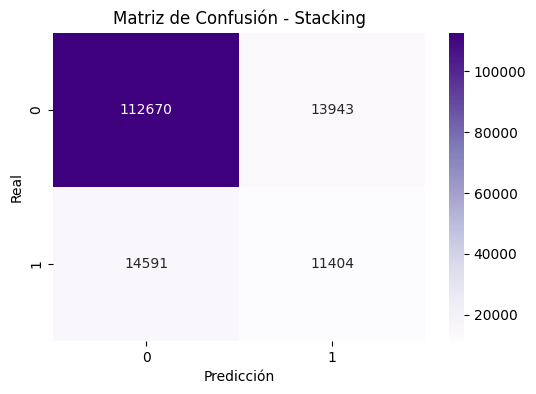

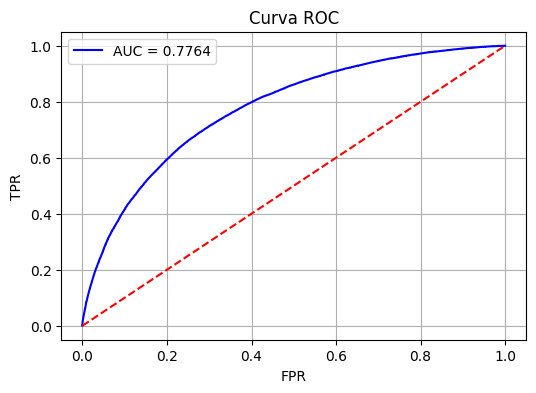

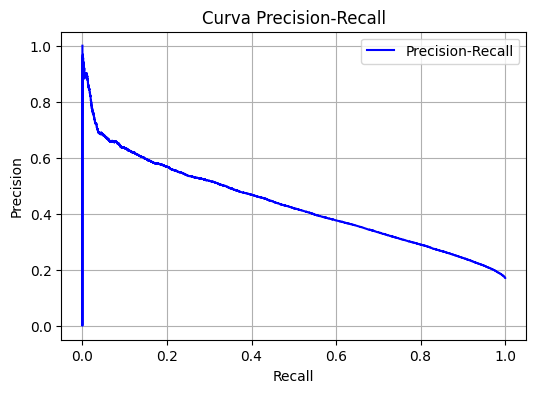

 Mejor umbral basado en F1: 0.36 (F1 = 0.4628)


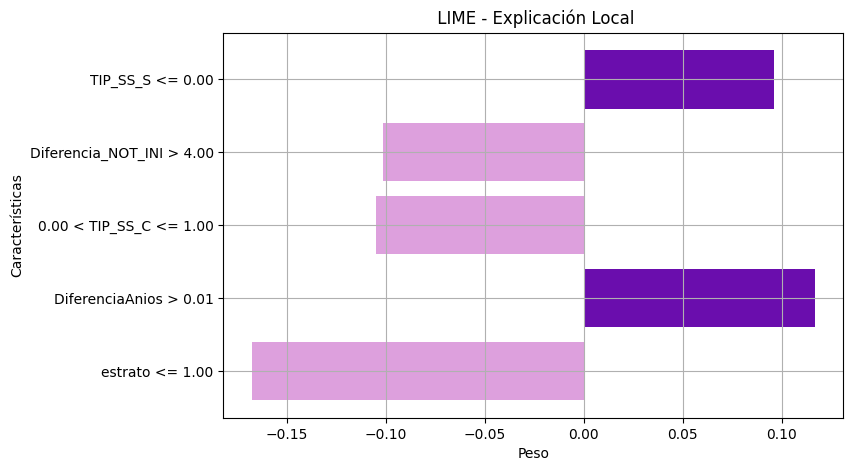

In [ ]:
X = Data.drop(columns=["Victima_Peligro", "Desenlace_Grave"])
y = Data["Victima_Peligro"]

#  División y balanceo con SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#  Modelos base
base_learners = [
    ('xgb', XGBClassifier(n_estimators=80, max_depth=4, learning_rate=0.1, n_jobs=-1, random_state=42)),
    ('lgbm', LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=42))
]

#  Meta-modelo
final_estimator = LogisticRegression(max_iter=200, solver='liblinear')

#  Stacking
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=final_estimator,
    cv=3,
    n_jobs=-1,
    passthrough=False
)

#  CPU Time
start_cpu = time.process_time()
stack_model.fit(X_train_smote, y_train_smote)
cpu_time = time.process_time() - start_cpu

#  Predicciones
y_pred = stack_model.predict(X_test)
y_proba = stack_model.predict_proba(X_test)[:, 1]

#  Métricas
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_proba)
summary = pd.DataFrame({
    "Precision (Macro)": [report["macro avg"]["precision"]],
    "Recall (Macro)": [report["macro avg"]["recall"]],
    "F1-score (Macro)": [report["macro avg"]["f1-score"]],
    "Accuracy": [report["accuracy"]],
    "AUC ROC": [roc_auc],
    "CPU Time (s)": [cpu_time]
})
display(HTML("<h3> Evaluación del Modelo Stacking (XGBoost + LightGBM)</h3>"))
display(summary.style.format("{:.4f}"))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Stacking")
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()

# Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_thresh_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_thresh_idx]
best_f1 = f1_scores[best_thresh_idx]

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color="blue", label="Precision-Recall")
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()
plt.show()

print(f" Mejor umbral basado en F1: {best_threshold:.2f} (F1 = {best_f1:.4f})")

#  LIME
explainer = LimeTabularExplainer(
    training_data=X_train_smote.values,
    feature_names=X_train_smote.columns.tolist(),
    class_names=["No Peligro", "Peligro"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

exp = explainer.explain_instance(X_test.iloc[0], stack_model.predict_proba, num_features=5)
lime_list = exp.as_list()
features, weights = zip(*lime_list)
colors = ['#6A0DAD' if w > 0 else '#DDA0DD' for w in weights]

plt.figure(figsize=(8, 5))
plt.barh(features, weights, color=colors)
plt.title(" LIME - Explicación Local")
plt.xlabel("Peso")
plt.ylabel("Características")
plt.grid(True)
plt.show()


### **Resultados del Modelo Stacking (XGBoost + LightGBM)**

El modelo de Stacking implementado con XGBoost y LightGBM como modelos base, y regresión logística como meta-modelo, obtuvo un desempeño destacable considerando la complejidad del problema y el desbalance de clases. La evaluación sobre el conjunto de prueba arrojó una métrica de **F1-score macro de 0.6659**, acompañada de una **precisión macro de 0.6676** y un **recall macro de 0.6643**. Estas métricas reflejan una capacidad equilibrada del modelo para identificar correctamente tanto a las víctimas en situación de peligro como a las que no lo están.

En términos de exactitud global, el modelo alcanzó un **accuracy del 81.30%**, mientras que el **área bajo la curva ROC (AUC) fue de 0.7764**, lo cual evidencia una buena capacidad de discriminación entre las dos clases. Un aspecto particularmente notable es la eficiencia computacional del modelo, que completó su entrenamiento en aproximadamente **1.5 segundos**, lo cual lo convierte en una opción viable para aplicaciones en tiempo real o en entornos con recursos limitados.

La matriz de confusión muestra que el modelo predijo correctamente **112,670 casos negativos (sin peligro) y 11,404 casos positivos (en peligro)**, mientras que se observaron **14,943 falsos positivos y 14,591 falsos negativos**. Aunque el número de falsos negativos aún es significativo —lo cual es crítico en contextos donde se busca proteger a posibles víctimas— el modelo logra mantener un equilibrio razonable entre sensibilidad y especificidad.

En la curva ROC se aprecia un comportamiento por encima de la diagonal de azar, validando la capacidad del modelo para distinguir entre clases. Por otro lado, la curva de precisión-recall muestra la típica caída pronunciada al aumentar el recall, debido al desbalance de clases, pero permite identificar un punto de compromiso óptimo. Al calcular el mejor umbral de decisión basado en la maximización del F1-score, se obtuvo un valor de **0.36**, con un **F1 ajustado de 0.4628**, lo que sugiere que el modelo podría beneficiarse de una calibración del umbral para mejorar la detección de los casos más críticos.

Desde el punto de vista interpretativo, se aplicó **LIME** para analizar las características más influyentes en la predicción de un caso específico. Las variables que aportaron más peso a la clasificación de "peligro" fueron: `TIP_SS_S` (relacionada con el tipo de afiliación en salud subsidiado), `Diferencia_NOT_INI` (diferencia entre el tiempo de notificación e inicio del violencia), `TIP_SS_C`, `DiferenciaAnios` (edad), y `estrato`. Se destaca que valores bajos de estrato y régimen subsidiado se asocian con mayor riesgo, lo cual coincide con los determinantes estructurales previamente identificados en la literatura sobre violencia de género en contextos vulnerables.

## **Comparación del Modelo Stacking vs. XGBoost Binario**

### **Análisis Comparativo**

Con el objetivo de desarrollar un modelo que no solo logre un buen desempeño predictivo, sino que también sea **eficiente en tiempo de ejecución**, se compararon dos enfoques avanzados: un modelo **XGBoost binario** y un modelo **Stacking Ensemble** que combina XGBoost y LightGBM como modelos base, y regresión logística como meta-modelo.

El modelo XGBoost binario obtuvo un **F1-score macro de 0.6792**, mientras que el modelo Stacking alcanzó un valor muy cercano de **0.6659**, lo que representa una pérdida de tan solo 1.3 puntos porcentuales. Sin embargo, esta leve reducción en desempeño viene acompañada de una **mejora drástica en el tiempo de entrenamiento**, pasando de **61.85 segundos en XGBoost a solo 1.51 segundos en Stacking**, es decir, una aceleración de más de **50 veces**.

Esta diferencia es crítica para contextos de salud pública en los que se requiere implementar modelos en sistemas de monitoreo continuo, o donde los recursos computacionales son limitados. En tales casos, **el modelo Stacking es claramente superior**, ya que permite decisiones oportunas con un compromiso aceptable en desempeño.

En términos de otras métricas, ambos modelos muestran resultados similares en *recall macro* (0.6566 vs. 0.6643) y *AUC* (0.8143 vs. 0.7764). Además, el modelo Stacking determinó un umbral óptimo más bajo (**0.36** frente a **0.47**), lo que sugiere un enfoque más conservador, útil para minimizar falsos negativos en eventos críticos.

Ambos modelos fueron interpretables mediante LIME, destacando variables socioeconómicas y relacionadas con el sistema de salud como principales factores asociados a riesgo, lo cual refuerza la coherencia de los resultados con el contexto de violencia basada en género.

### **Tabla de Comparación**

| Métrica                        | XGBoost Binario      | Stacking (XGB + LGBM) |
|-------------------------------|----------------------|------------------------|
| **Precision (Macro)**         | 0.7232               | 0.6676                 |
| **Recall (Macro)**            | 0.6566               | 0.6643                 |
| **F1-score (Macro)**          | **0.6792**           | 0.6659                 |
| **Accuracy**                  | 0.8446               | 0.8130                 |
| **AUC ROC**                   | **0.8143**           | 0.7764                 |
| **Tiempo de entrenamiento (s)** | 61.85              | **1.51**               |
| **Mejor umbral (F1 óptimo)** | 0.47                 | **0.36**               |
| **F1-score en umbral óptimo** | 0.4628              | 0.4628                 |
| **Explicabilidad (LIME)**     | Sí                   | Sí                     |

### **Conclusión**

Aunque el modelo XGBoost binario mostró un rendimiento levemente superior en métricas como F1-score macro y AUC, el modelo de **Stacking se posiciona como la mejor opción global** al ofrecer resultados competitivos con **una eficiencia computacional significativamente mayor**. Esto lo convierte en el candidato ideal para ser implementado como modelo base en herramientas de monitoreo e intervención en casos de violencia basada en género, especialmente en entornos donde la **rapidez en el análisis y la escalabilidad son prioridades fundamentales**.


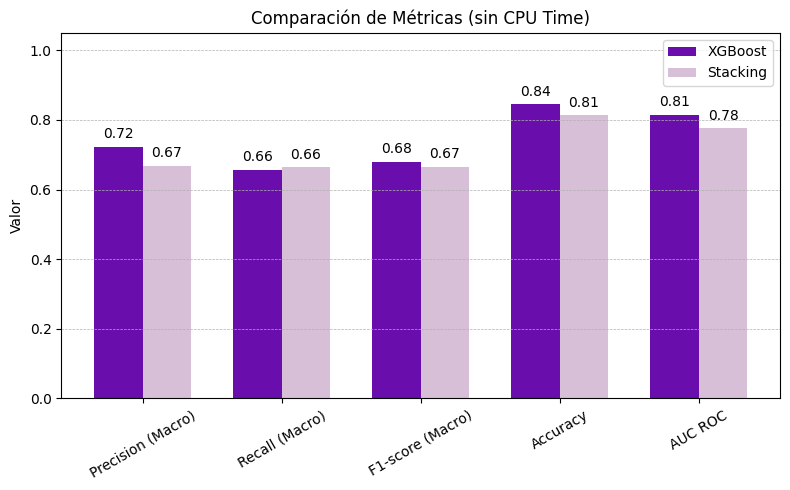

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
metrics_no_cpu = ['Precision (Macro)', 'Recall (Macro)', 'F1-score (Macro)', 'Accuracy', 'AUC ROC']
xgboost_vals_no_cpu = [0.7232, 0.6566, 0.6792, 0.8446, 0.8143]
stacking_vals_no_cpu = [0.6676, 0.6643, 0.6659, 0.8130, 0.7764]
x = np.arange(len(metrics_no_cpu))
width = 0.35

# Gráfico
fig1, ax1 = plt.subplots(figsize=(8, 5))
bars1 = ax1.bar(x - width/2, xgboost_vals_no_cpu, width, label='XGBoost', color='#6A0DAD')
bars2 = ax1.bar(x + width/2, stacking_vals_no_cpu, width, label='Stacking', color='#D8BFD8')

ax1.set_ylabel('Valor')
ax1.set_ylim(0, 1.05)  # espacio extra arriba
ax1.set_title('Comparación de Métricas (sin CPU Time)')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_no_cpu, rotation=30)
ax1.legend()
ax1.grid(True, axis='y', linestyle='--', linewidth=0.5)

# Etiquetas
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 4),
                     textcoords="offset points",
                     ha='center', va='bottom')

plt.tight_layout()
plt.show()


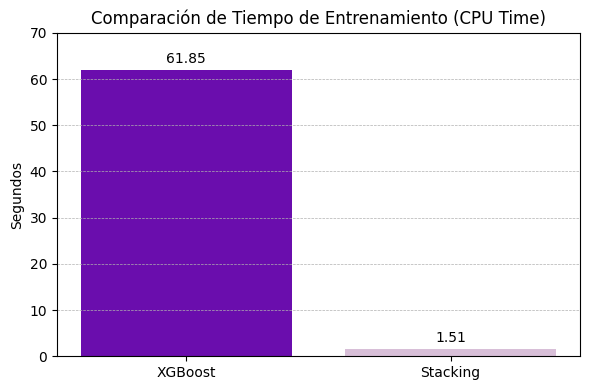

In [ ]:
# Gráfico de CPU Time
fig2, ax2 = plt.subplots(figsize=(6, 4))
xgboost_cpu = 61.85
stacking_cpu = 1.51
bars_cpu = ax2.bar(['XGBoost', 'Stacking'], [xgboost_cpu, stacking_cpu], color=['#6A0DAD', '#D8BFD8'])

ax2.set_ylabel('Segundos')
ax2.set_ylim(0, 70)  # espacio extra arriba
ax2.set_title('Comparación de Tiempo de Entrenamiento (CPU Time)')
ax2.grid(True, axis='y', linestyle='--', linewidth=0.5)

# Etiquetas
for bar in bars_cpu:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()


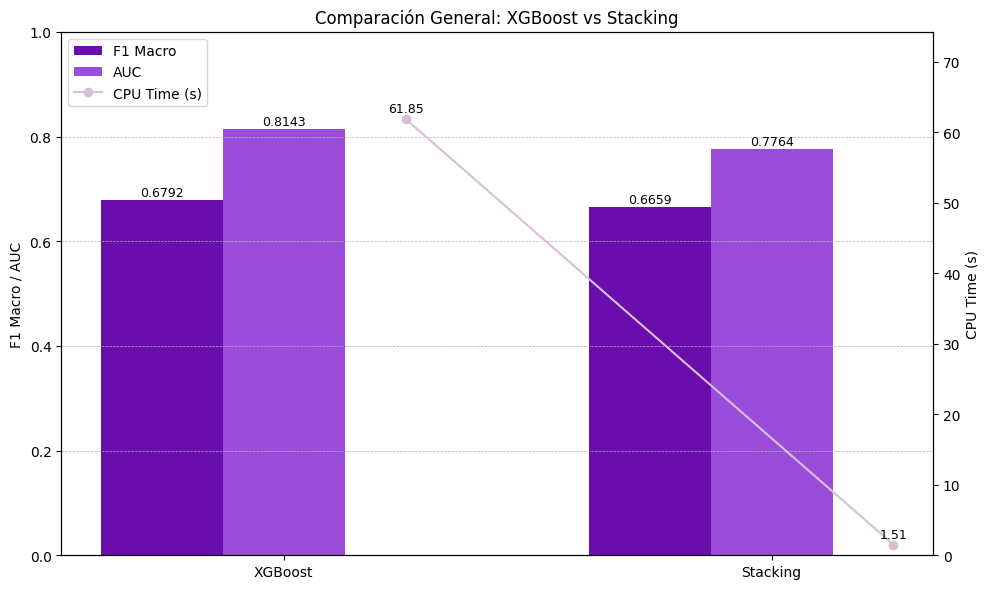

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
modelos = ["XGBoost", "Stacking"]
f1_macro = [0.6792, 0.6659]
auc = [0.8143, 0.7764]
cpu_time = [61.85, 1.51]

x = np.arange(len(modelos))
width = 0.25

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras para F1 Macro y AUC
bar1 = ax1.bar(x - width, f1_macro, width=width, label='F1 Macro', color='#6A0DAD')
bar2 = ax1.bar(x, auc, width=width, label='AUC', color='#9A4DDA')

ax1.set_ylabel('F1 Macro / AUC')
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(modelos)
ax1.set_title("Comparación General: XGBoost vs Stacking")
ax1.grid(True, axis='y', linestyle='--', linewidth=0.5)

# Etiquetas sobre barras
for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.4f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', fontsize=9)

# Segundo eje para CPU Time
ax2 = ax1.twinx()
line = ax2.plot(x + width, cpu_time, marker='o', linestyle='-', color='#D8BFD8', label='CPU Time (s)')
ax2.set_ylabel('CPU Time (s)')
ax2.set_ylim(0, max(cpu_time) * 1.2)

# Etiquetas para línea de CPU Time
for i, val in enumerate(cpu_time):
    ax2.annotate(f'{val:.2f}',
                 xy=(x[i] + width, val),
                 xytext=(0, 5),
                 textcoords="offset points",
                 ha='center', fontsize=9)

# Leyenda combinada
handles = [bar1[0], bar2[0], line[0]]
labels = ['F1 Macro', 'AUC', 'CPU Time (s)']
ax1.legend(handles, labels, loc='upper left')

plt.tight_layout()
plt.show()


## **Conclusión General**

A lo largo de este proyecto se implementaron y evaluaron diversos modelos de clasificación con el objetivo de predecir desenlaces graves en víctimas de violencia basada en género en Colombia. Se enfrentó un problema complejo y altamente desbalanceado, donde el reto principal no solo era alcanzar un buen rendimiento en métricas como F1 macro, sino también asegurar eficiencia computacional para una futura implementación práctica.

En este contexto, el modelo de **Stacking (XGBoost + LightGBM)** se destacó como la **mejor alternativa global**. Si bien mostró un F1 macro apenas inferior al de XGBoost binario, logró este desempeño en **menos de 2 segundos de entrenamiento**, frente a los más de 60 segundos requeridos por XGBoost. Esta ventaja en velocidad, manteniendo al mismo tiempo una alta capacidad de predicción, lo posiciona como un modelo robusto, eficiente y viable para escenarios reales de monitoreo y decisión temprana.

```{note}

Este proyecto fue desarrollado únicamente con la información contenida en la primera hoja del formulario oficial "875_Violencia_Genero_2024", lo cual limitó el uso de variables clave para caracterizar la violencia (tipo, contexto, perfil del agresor, etc.). En etapas futuras, se trabajará en conjunto con expertos del área y se utilizará el formulario completo, con el fin de **incorporar variables contextuales relevantes** que podrían mejorar la precisión del modelo y permitir una clasificación más fina y accionable.
```

```{note}
La siguiente sección presenta la evaluación comparativa de otros modelos implementados durante el desarrollo del proyecto. Se incluyen modelos probados tanto en el escenario binario como en el multiclase. Aunque algunos ofrecen buenos resultados parciales, **ninguno logra superar el rendimiento combinado en F1 macro y eficiencia del modelo de Stacking ni del XGBoost binario**, los cuales se consolidan como las mejores opciones en este estudio.
```